[data dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction import DictVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

pd.set_option('display.max_rows', 200)
%matplotlib inline

In [2]:
# MLflow
import mlflow

mlflow.set_experiment('nyt-taxi-duration')

/Users/mattfelici/miniconda3/envs/mlops/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Experiment: artifact_location='/Users/mattfelici/personal/learning/mlops-zoomcamp/02-experiment-tracking/mlruns/1', creation_time=1778250251068, experiment_id='1', last_update_time=1778250251068, lifecycle_stage='active', name='nyt-taxi-duration', tags={}, trace_location=None, workspace='default'>

In [3]:
# df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2026-01.parquet')
df = pd.read_parquet('../data/yellow_tripdata_2026-01.parquet')

print(df.shape)
print(df.dtypes)
df.head()

(3724889, 20)
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
VendorID,3724889.0,1.873598,1.0,2.0,2.0,2.0,7.0,0.701458
tpep_pickup_datetime,3724889,2026-01-17 01:44:52.106518,2025-12-31 23:57:29,2026-01-09 17:51:59,2026-01-16 21:20:56,2026-01-24 07:25:11,2026-02-01 00:45:01,NaN
tpep_dropoff_datetime,3724889,2026-01-17 02:02:03.696138,2025-12-31 23:57:32,2026-01-09 18:08:47,2026-01-16 21:36:14,2026-01-24 07:40:22,2026-02-01 23:35:31,NaN
passenger_count,2636831.0,1.256271,0.0,1.0,1.0,1.0,9.0,0.670243
trip_distance,3724889.0,6.455647,0.0,1.0,1.81,3.73,269097.48,648.885528
RatecodeID,2636831.0,5.218853,1.0,1.0,1.0,1.0,99.0,19.653699
PULocationID,3724889.0,161.43719,1.0,114.0,161.0,233.0,265.0,67.066574
DOLocationID,3724889.0,160.99357,1.0,107.0,162.0,234.0,265.0,71.03604
payment_type,3724889.0,0.846564,0.0,0.0,1.0,1.0,4.0,0.712049
fare_amount,3724889.0,20.804254,-2555.2,10.0,15.6,26.1,2555.2,18.927007


In [5]:
def feature_engineering(df):
    # Duration
    df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    df = df.loc[df['duration'].between(1, 60)]
    
    # Date info
    df['dow'] = df['tpep_pickup_datetime'].dt.day_name()
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

    # Pairing locations
    df['locationID'] = df['PULocationID'].astype(str) + '_' + df['DOLocationID'].astype(str)

    return df

def preprocessing(df, categorical, numerical, tgt='duration'):

    dv = DictVectorizer(separator='_')
    tmp = df[categorical + numerical]
    tmp[categorical] = tmp[categorical].astype(str)
    y = df[tgt]
    
    X_train, X_val, y_train, y_val = train_test_split(tmp, y, train_size=0.8)
    X_train = dv.fit_transform(X_train.to_dict(orient='records'))

    X_val = dv.transform(X_val.to_dict(orient='records'))
    
    return X_train, X_val, y_train, y_val


def complete_preparation(df, categorical, numerical, tgt='duration'):

    df = feature_engineering(df)
    return preprocessing(df, categorical, numerical, tgt)

In [6]:
# Feature list
# categorical = ['PULocationID', 'DOLocationID', 'dow', 'pickup_hour']
categorical = ['locationID', 'dow', 'pickup_hour']
numerical = ['trip_distance']
tgt = 'duration'

X_train, X_val, y_train, y_val = complete_preparation(df, categorical, numerical, tgt=tgt)

/var/folders/ty/vy_xnc9503lgj7fc9h6qd5m80000gn/T/ipykernel_53062/1514377924.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['dow'] = df['tpep_pickup_datetime'].dt.day_name()
/var/folders/ty/vy_xnc9503lgj7fc9h6qd5m80000gn/T/ipykernel_53062/1514377924.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
/var/folders/ty/vy_xnc9503lgj7fc9h6qd5m80000gn/T/ipykernel_53062/1514377924.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of

count    3.724889e+06
mean     1.719316e+01
std      2.517802e+01
min     -1.170000e+01
25%      8.066667e+00
50%      1.336667e+01
75%      2.120000e+01
90%      3.225000e+01
95%      4.275000e+01
max      7.507900e+03
Name: duration, dtype: float64


<Axes: xlabel='duration', ylabel='Count'>

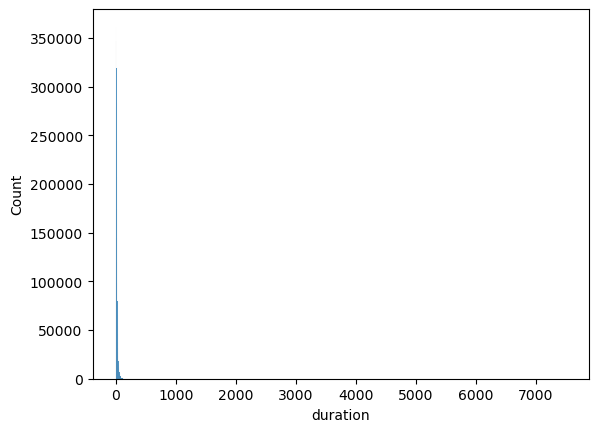

In [8]:
print(df['duration'].describe(percentiles=[.25, .5, .75, .9, .95]))
sns.histplot(df['duration'])

5.557073458552681


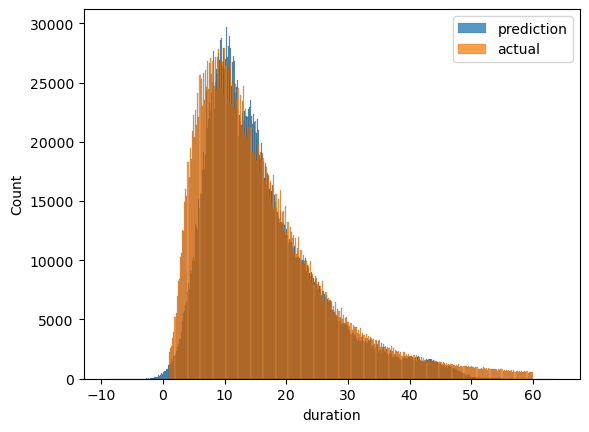

In [12]:
# Prediction
lr = Ridge(alpha=0.01) # LinearRegression()
lr.fit(X_train, y_train)

pred_train = lr.predict(X_train)
print(root_mean_squared_error(y_train, pred_train))

# Plot
sns.histplot(pred_train, label='prediction')
sns.histplot(y_train, label='actual')
plt.legend()
plt.show()

5.669695688405353


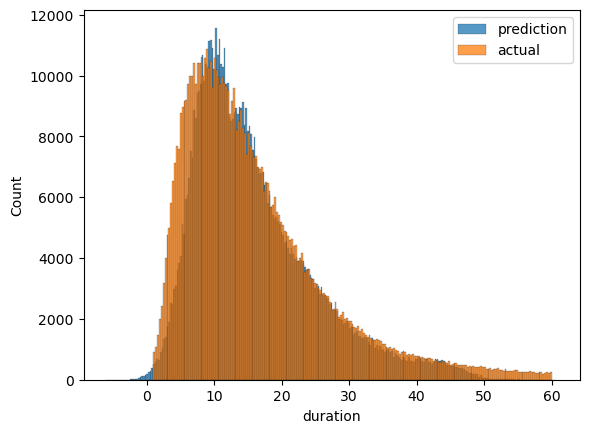

In [13]:
# Check validation data
pred_val = lr.predict(X_val)
print(root_mean_squared_error(y_val, pred_val))

# Plot
sns.histplot(pred_val, label='prediction')
sns.histplot(y_val, label='actual')
plt.legend()
plt.show()

In [14]:
with mlflow.start_run():

    mlflow.set_tag('dev', 'mattfelici')
    mlflow.log_param('data-path', '../data/yellow_tripdata_2026-01.parquet')

    alpha = 0.01
    mlflow.log_param('alpha', alpha)
    lr = Ridge(alpha=alpha)
    mlflow.set_tag('model-type', 'Ridge')
    lr.fit(X_train, y_train)
    
    pred_train = lr.predict(X_train)
    rmse_train = root_mean_squared_error(y_train, pred_train)
    mlflow.log_metric('RMSE-train', rmse_train)
    
    pred_val = lr.predict(X_val)
    rmse_val = root_mean_squared_error(y_val, pred_val)
    mlflow.log_metric('RMSE-val', rmse_val)


In [15]:
with mlflow.start_run():

    mlflow.set_tag('dev', 'mattfelici')
    mlflow.log_param('data-path', '../data/yellow_tripdata_2026-01.parquet')

    lr = LinearRegression()
    mlflow.set_tag('model-type', 'LinearRegression')
    lr.fit(X_train, y_train)
    
    pred_train = lr.predict(X_train)
    rmse_train = root_mean_squared_error(y_train, pred_train)
    mlflow.log_metric('RMSE-train', rmse_train)
    
    pred_val = lr.predict(X_val)
    rmse_val = root_mean_squared_error(y_val, pred_val)
    mlflow.log_metric('RMSE-val', rmse_val)


In [71]:
# Write output model
with open('lin_reg.bin', 'wb') as f:
    pickle.dump((dv, lr), f)

## Hyperparameter tuning with Hyperopt + XGB

In [7]:
import xgboost as xgb
import optuna

In [8]:
train = xgb.DMatrix(X_train, label=y_train)
val = xgb.DMatrix(X_val, label=y_val)

In [11]:
def optimize(trial):

    with mlflow.start_run(nested=True, run_name=f'trial_{trial.number}') as child_run:
        mlflow.set_tag('dev', 'mattfelici')
        mlflow.set_tag('model-type', 'XGBoost')
        mlflow.set_tag('model-optimization', 'hyperopt')

        params = {
            'max_depth': trial.suggest_int('max_depth', 4, 25),
            'learning_rate': trial.suggest_float('learning_rate', 1e-2, 1e0, log=True),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 1e-1, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-6, 1e-1, log=True),
            'min_child_weight': trial.suggest_float('min_child_weight', 1e-1, 1e3, log=True),
            'objective': 'reg:squarederror',
            'seed': 42
        }
        
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=100,
            evals=[(val, 'validation')],
            early_stopping_rounds=50
        )
        pred_train = booster.predict(train)
        rmse_train = root_mean_squared_error(y_train, pred_train)
        mlflow.log_metric('RMSE-train', rmse_train)
        
        pred_val = booster.predict(val)
        rmse_val = root_mean_squared_error(y_val, pred_val)
        mlflow.log_metric('RMSE-val', rmse_val) 

        trial.set_user_attr("run_id", child_run.info.run_id)

        return rmse_val

In [10]:
with mlflow.start_run(run_name='XGB hyperparam opt') as run:

    n_trials = 10
    mlflow.log_param('N trials', n_trials)
    
    study = optuna.create_study(direction="minimize")
    study.optimize(optimize, n_trials=n_trials)
    
    # Log the best trial and its run ID
    mlflow.log_params(study.best_trial.params)
    mlflow.log_metrics({'best loss': study.best_value})
    if best_run_id := study.best_trial.user_attrs.get('run_id'):
        mlflow.log_param('best_child_run_id', best_run_id)

[I 2026-05-12 17:20:57,747] A new study created in memory with name: no-name-d94a785a-9690-4417-9b37-621a182953db


[0]	validation-rmse:10.61988
[1]	validation-rmse:10.58247
[2]	validation-rmse:10.54530
[3]	validation-rmse:10.50838
[4]	validation-rmse:10.47170
[5]	validation-rmse:10.43528
[6]	validation-rmse:10.39909
[7]	validation-rmse:10.36312
[8]	validation-rmse:10.32741
[9]	validation-rmse:10.29193
[10]	validation-rmse:10.25668
[11]	validation-rmse:10.22167
[12]	validation-rmse:10.18685
[13]	validation-rmse:10.15231
[14]	validation-rmse:10.11794
[15]	validation-rmse:10.08386
[16]	validation-rmse:10.04995
[17]	validation-rmse:10.01633
[18]	validation-rmse:9.98287
[19]	validation-rmse:9.94971
[20]	validation-rmse:9.91670
[21]	validation-rmse:9.88398
[22]	validation-rmse:9.85143
[23]	validation-rmse:9.81915
[24]	validation-rmse:9.78702
[25]	validation-rmse:9.75520
[26]	validation-rmse:9.72357
[27]	validation-rmse:9.69205
[28]	validation-rmse:9.66089
[29]	validation-rmse:9.62983
[30]	validation-rmse:9.59908
[31]	validation-rmse:9.56844
[32]	validation-rmse:9.53808
[33]	validation-rmse:9.50786
[34]	v

[I 2026-05-12 17:30:50,470] Trial 0 finished with value: 7.922159894396129 and parameters: {'max_depth': 19, 'learning_rate': 0.005051483941265407, 'reg_alpha': 0.041778347364210475, 'reg_lambda': 0.000554356807519084, 'min_child_weight': 2.705284109513105}. Best is trial 0 with value: 7.922159894396129.


[0]	validation-rmse:10.41474
[1]	validation-rmse:10.18315
[2]	validation-rmse:9.96242
[3]	validation-rmse:9.75171
[4]	validation-rmse:9.55061
[5]	validation-rmse:9.35915
[6]	validation-rmse:9.17629
[7]	validation-rmse:9.00231
[8]	validation-rmse:8.83661
[9]	validation-rmse:8.67898
[10]	validation-rmse:8.52930
[11]	validation-rmse:8.38645
[12]	validation-rmse:8.25138
[13]	validation-rmse:8.12237
[14]	validation-rmse:8.00035
[15]	validation-rmse:7.88438
[16]	validation-rmse:7.77479
[17]	validation-rmse:7.67080
[18]	validation-rmse:7.57203
[19]	validation-rmse:7.47874
[20]	validation-rmse:7.39003
[21]	validation-rmse:7.30623
[22]	validation-rmse:7.22653
[23]	validation-rmse:7.15174
[24]	validation-rmse:7.08059
[25]	validation-rmse:7.01343
[26]	validation-rmse:6.94922
[27]	validation-rmse:6.88926
[28]	validation-rmse:6.83241
[29]	validation-rmse:6.77883
[30]	validation-rmse:6.72783
[31]	validation-rmse:6.67950
[32]	validation-rmse:6.63332
[33]	validation-rmse:6.59073
[34]	validation-rmse:6

[I 2026-05-12 17:31:49,980] Trial 1 finished with value: 5.812408675914575 and parameters: {'max_depth': 11, 'learning_rate': 0.034379892830329495, 'reg_alpha': 0.00012739545840344675, 'reg_lambda': 2.3815216109034407e-05, 'min_child_weight': 0.1007432152696452}. Best is trial 1 with value: 5.812408675914575.


In [6]:
import mlflow
import optuna
import sklearn


def objective(trial):
    # Setting nested=True will create a child run under the parent run.
    with mlflow.start_run(nested=True, run_name=f"trial_{trial.number}") as child_run:
        rf_max_depth = trial.suggest_int("rf_max_depth", 2, 32)
        rf_n_estimators = trial.suggest_int("rf_n_estimators", 50, 300, step=10)
        rf_max_features = trial.suggest_float("rf_max_features", 0.2, 1.0)
        params = {
            "max_depth": rf_max_depth,
            "n_estimators": rf_n_estimators,
            "max_features": rf_max_features,
        }
        # Log current trial's parameters
        mlflow.log_params(params)

        regressor_obj = sklearn.ensemble.RandomForestRegressor(**params)
        regressor_obj.fit(X_train, y_train)

        y_pred = regressor_obj.predict(X_val)
        error = sklearn.metrics.mean_squared_error(y_val, y_pred)
        # Log current trial's error metric
        mlflow.log_metrics({"error": error})

        # Log the model file
        mlflow.sklearn.log_model(regressor_obj, name="model")
        # Make it easy to retrieve the best-performing child run later
        trial.set_user_attr("run_id", child_run.info.run_id)
        return error


In [ ]:
# Create a parent run that contains all child runs for different trials
with mlflow.start_run(run_name="study") as run:
    # Log the experiment settings
    n_trials = 2
    mlflow.log_param("n_trials", n_trials)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    # Log the best trial and its run ID
    mlflow.log_params(study.best_trial.params)
    mlflow.log_metrics({"best_error": study.best_value})
    if best_run_id := study.best_trial.user_attrs.get("run_id"):
        mlflow.log_param("best_child_run_id", best_run_id)

[I 2026-05-12 17:19:11,606] A new study created in memory with name: no-name-ba13ca43-af27-415a-ba71-1c4a88e58c9f
